In [30]:
import polars as pl
from pathlib import Path

path = Path("../data/Airlink - UMichiagn - Data Collection - 9.8.2025.xlsx")
df = pl.read_excel(path, read_options={"header_row": 1})

In [31]:
# add col called diff which is GIK - Long
df = df.with_columns((pl.col("GIK Value Delivered by Airlink (=Value delivered - NGO payments - Invoiced)") - pl.col("Commercial Cost for Long-Haul")).alias("diff"))
pl.Config.set_tbl_rows(15)

df2 = df.filter([
    pl.col("diff").le(0)
])
display(df2)
# display(df)
# # Convert to Pandas DataFrame
# df_pandas = df.to_pandas()

# # Apply sticky header using Pandas Styler
# df_pandas.style.set_sticky(axis="columns")
# # display all rows
# import pandas as pd
# pd.set_option('display.max_rows', None)
# display(df_pandas)

# NOTE
"""
Intuition, where diff is positive 
"""

NGO ID,Shipment ID,Received,Deadline Date,Origin,Destination,Cargo Ready Date,Depart,Arrive,Forwarder,AWB #,Airlink Partner,Aircraft Type,AW (kg),CBM,Pallets,Incoterms,Last-mile Requested,Consignee,NGO Payments,Commercial Cost for First Mile,Commercial Cost for Long-Haul,Commercial Cost for Last Mile,Total Value Delivered,GIK Value Delivered by Airlink (=Value delivered - NGO payments - Invoiced),Airline,Valuation Source,diff
str,str,date,str,str,str,date,date,date,str,str,str,str,f64,f64,f64,str,str,str,f64,f64,f64,f64,f64,f64,str,str,f64
"""NP015""","""24-0315""",2024-10-02,"""2024-10-10""","""YYZ""","""PAP""",2024-10-03,2025-02-07,2025-02-20,"""PWS""","""001-86266633""","""American Airlines""","""Narrowbody""",264.45,1.887,3.0,"""CPT""","""Yes""","""CENTRE MEDICAL BERACA - Dr. Al…",null,533.66,4690.0,null,5223.66,4690.0,"""American Airlines""","""Online Calculator""",0.0
"""NP187""","""24-0337""",2024-12-10,"""2024-12-10""","""DXB""","""BEY""",2024-12-16,2025-01-05,2025-01-05,"""PWS""","""076-43047911""","""Commercial""","""Widebody""",704.0,2.688,2.0,"""DAT""","""No""","""YMCA of Lebanon, Delta Center,…",0.0,0.0,3790.0,0.0,3790.0,0.0,"""Commercial""","""Commercial Rate""",-3790.0
"""NP015""","""24-0341""",2024-12-19,"""2025-01-10""","""YYZ""","""TLV""",2025-01-02,2025-02-13,2025-02-15,"""PWS""","""700-74270232""","""Commercial""","""Widebody""",1583.0,5.664,4.0,"""CPT""","""No""","""ANERA 13 NABLUS ROAD SHE…",null,1638.66,8801.0,null,10439.66,0.0,"""Commercial""","""Commercial Rate""",-8801.0
"""NP269""","""24-0342""",2024-12-24,"""2024-12-26""","""JAX""","""VLI""",2024-12-24,2025-01-13,2025-01-17,"""PWS""","""260-40755245""","""United Airlines, Fiji Airways""","""Narrowbody""",108.42,1.0069,1.0,"""CPT""","""No""","""Peter Judge Vanuatu Business R…",0.0,1999.43,3158.0,0.0,5157.43,3158.0,"""United Airlines, Fiji Airways""","""Online Calculator""",0.0
"""NP285,NP127""","""24-0344""",2024-12-30,"""2025-01-06""","""LGG""","""NDJ""",2024-12-30,2025-01-24,2025-02-09,"""SEKO""","""071-54528585""","""Commercial""","""Widebody""",1886.0,7.727,6.0,"""DAP""","""Yes""","""INTERSOS Sudan Geneina Office …",0.0,1378.69,9851.24,15605.89,26835.82,-17186.13,"""Commercial""","""Commercial Rate""",-27037.37
"""NP224""","""24-0345""",2024-12-30,"""2025-01-06""","""SHJ""","""NDJ""",2025-01-06,2025-01-25,2025-02-12,"""SEKO""","""071-55544366""","""Commercial""","""Freighter""",16474.0,154.67,116.0,"""DAP""","""Yes""","""NTERSOS SUDAN Binay Basyal H…",0.0,9166.65,148229.25,185150.98,342546.88,13750.0,"""Commercial""","""Commercial Rate""",-134479.25
"""NP206""","""24-0360""",2024-12-13,"""2024-11-25""","""MIA""","""PAP""",null,2025-02-25,2025-03-11,"""PWS""","""810-43041515""","""Amerijet""","""Freighter""",127.913,0.666,1.0,"""DAP""",null,"""Parole and Action""",null,1211.64,384.0,null,1595.64,0.0,"""Amerijet""","""Commercial Rate""",-384.0
"""NP090""","""25-0002""",2025-01-06,"""2025-02-07""","""MIA""","""PAP""",2025-01-06,2025-03-03,2025-03-07,"""SEKO""","""810-40120452""","""Amerijet""","""Freighter""",70.7604,0.912,1.0,"""CIP""","""No""","""Partners In Health Zanmi Lasan…",null,1750.0,378.0,null,2128.0,0.0,"""Amerijet""","""Commercial Rate""",-378.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…


'\nIntuition, where diff is positive \n'

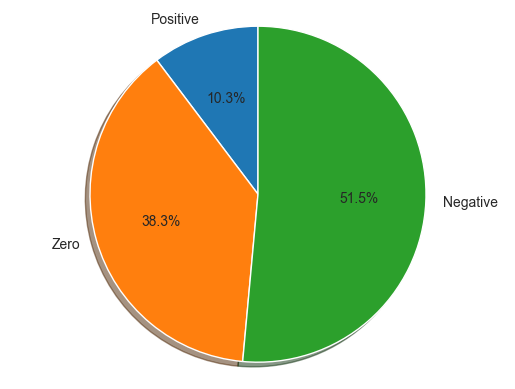

In [32]:
# make a pie chart of the share of positive, zero and negative diff
import matplotlib.pyplot as plt

# Count the number of positive, zero, and negative diffs
labels = ['Positive', 'Zero', 'Negative']
sizes = [
    df.filter(pl.col("diff") > 0).shape[0],
    df.filter(pl.col("diff") == 0).shape[0],
    df.filter(pl.col("diff") < 0).shape[0]
]

# Plot
fig, ax = plt.subplots()
ax.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    shadow=True,
    startangle=90
)
ax.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle

plt.show()

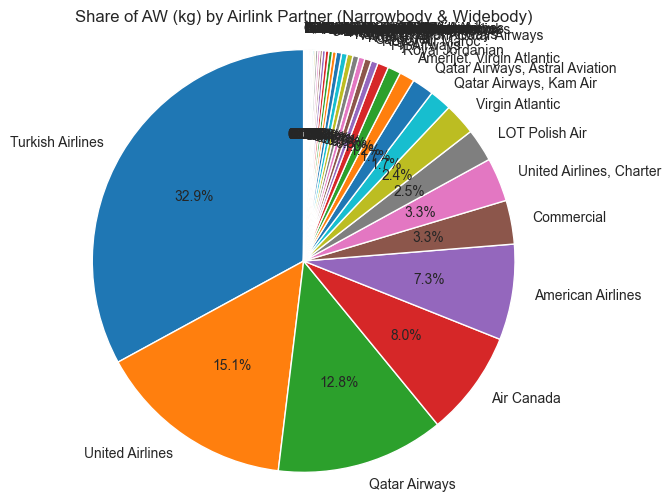

In [33]:
#  Filter rows for Narrowbody or Widebody
df_filtered = df.filter(
    pl.col("Aircraft Type").is_in(["Narrowbody", "Widebody"])
)

# Group by Airlink Partner and sum AW (kg)
df_sum = (
    df_filtered
    .group_by("Airlink Partner")
    .agg(pl.col("AW (kg)").sum().alias("Total_AW"))
    .sort("Total_AW", descending=True)
)

# Extract labels and values
labels = df_sum["Airlink Partner"].to_list()
sizes = df_sum["Total_AW"].to_list()

# Plot pie chart
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)
ax.axis('equal')  # Equal aspect ratio ensures the pie is circular
plt.title("Share of AW (kg) by Airlink Partner (Narrowbody & Widebody)")

plt.show()

C:\Users\mborrero\AppData\Local\Temp\ipykernel_60036\460868389.py:30: UserWarning: Comparisons with None always result in null. Consider using `.is_null()` or `.is_not_null()`.
  subset = df_grouped.filter(pl.col("Year") == year)


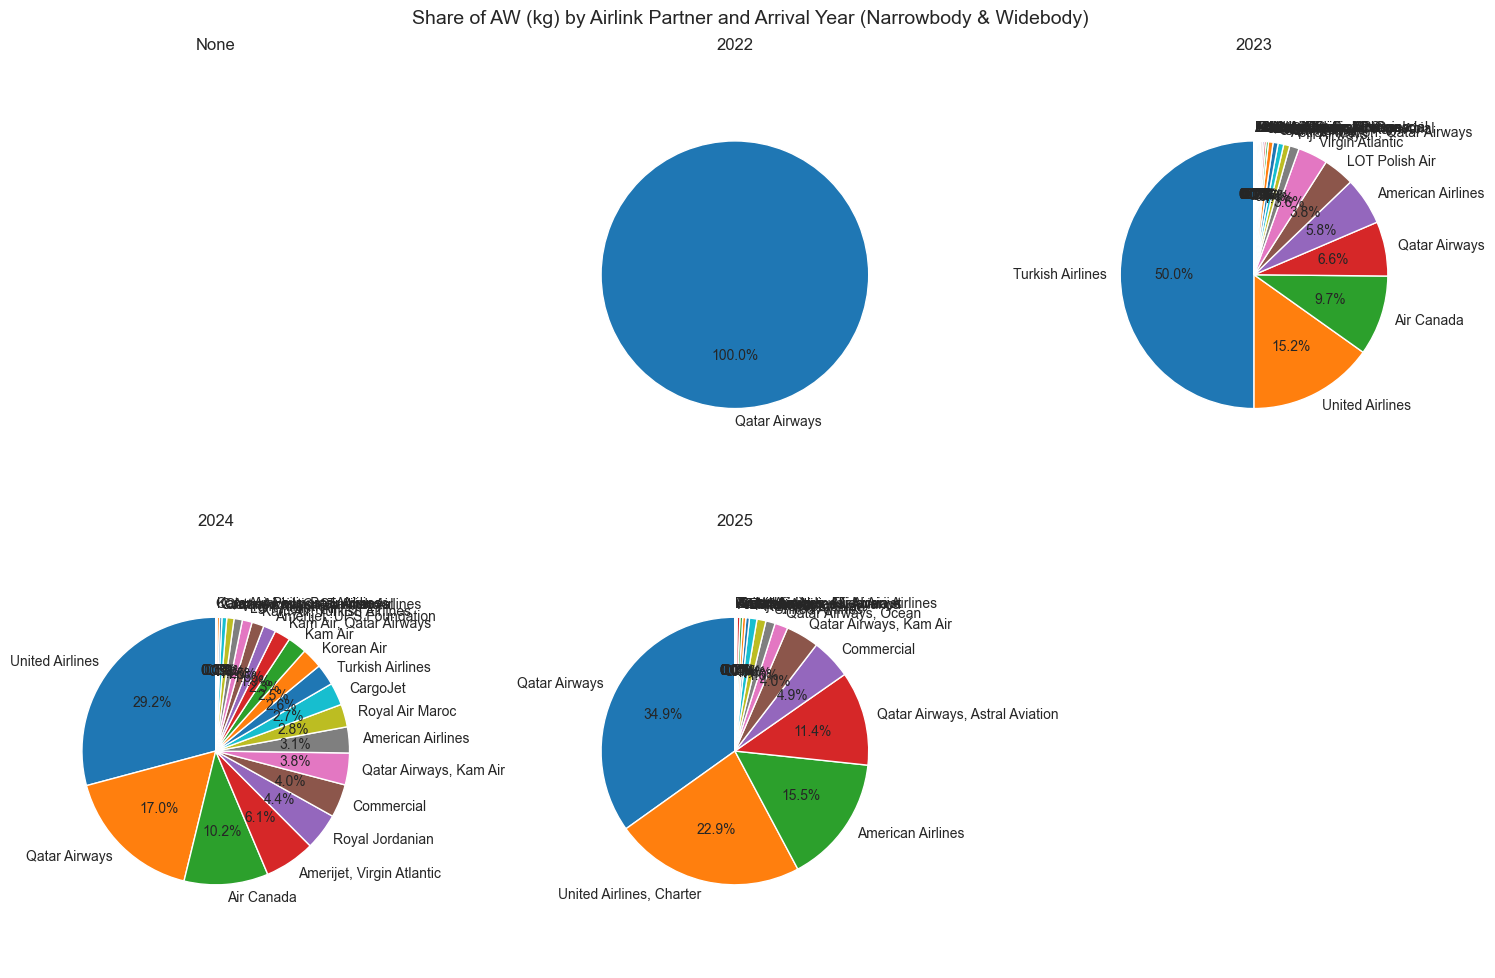

In [34]:
# Filter for Narrowbody and Widebody only
df_filtered = df.filter(
    pl.col("Aircraft Type").is_in(["Narrowbody", "Widebody"])
)

# If Arrive is already a date, extract year directly
df_filtered = df_filtered.with_columns(
    pl.col("Arrive").dt.year().alias("Year")
)

# Group by Year and Airlink Partner, summing AW (kg)
df_grouped = (
    df_filtered
    .group_by(["Year", "Airlink Partner"])
    .agg(pl.col("AW (kg)").sum().alias("Total_AW"))
    .sort(["Year", "Total_AW"], descending=[True, True])
)

# Get list of years
years = df_grouped["Year"].unique().sort()

# Prepare subplots (e.g., 3 columns)
cols = 3
rows = -(-len(years) // cols)  # ceiling division
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
axes = axes.flatten()

# Plot one pie per year
for i, year in enumerate(years):
    subset = df_grouped.filter(pl.col("Year") == year)
    labels = subset["Airlink Partner"].to_list()
    sizes = subset["Total_AW"].to_list()
    
    axes[i].pie(
        sizes,
        labels=labels,
        autopct='%1.1f%%',
        startangle=90
    )
    axes[i].axis('equal')
    axes[i].set_title(f"{year}")

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Share of AW (kg) by Airlink Partner and Arrival Year (Narrowbody & Widebody)", fontsize=14)
plt.tight_layout()
plt.show()

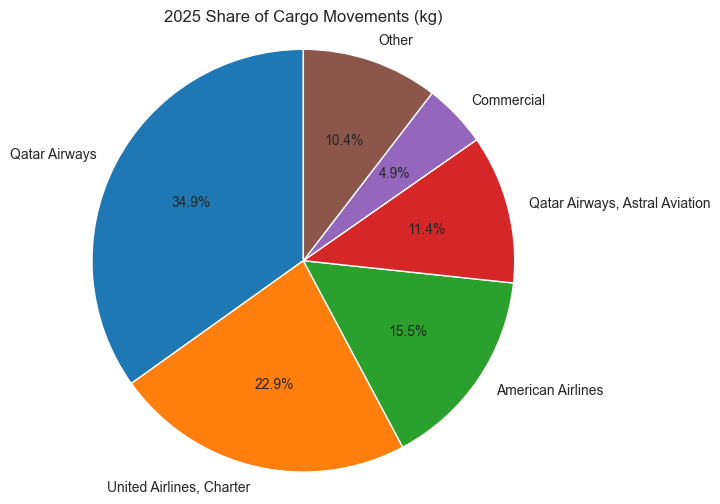

In [35]:
# Filter for Narrowbody and Widebody only
df_filtered = df.filter(
    pl.col("Aircraft Type").is_in(["Narrowbody", "Widebody"])
)

# Extract year from Arrive (if it's a date)
df_filtered = df_filtered.with_columns(
    pl.col("Arrive").dt.year().alias("Year")
)

# Group by Year and Airlink Partner, summing AW (kg)
df_grouped = (
    df_filtered
    .group_by(["Year", "Airlink Partner"])
    .agg(pl.col("AW (kg)").sum().alias("Total_AW"))
    .sort(["Year", "Total_AW"], descending=[True, True])
)

# --- Focus only on 2025 ---
df_2025 = df_grouped.filter(pl.col("Year") == 2025)

# --- Keep only top 5 and combine others into 'Other' ---
df_top5 = df_2025.sort("Total_AW", descending=True).head(5)
top5_partners = df_top5["Airlink Partner"].to_list()

# Compute 'Other' category if applicable
other_sum = (
    df_2025.filter(~pl.col("Airlink Partner").is_in(top5_partners))["Total_AW"].sum()
)

# Match dtype of Year column
year_dtype = df_top5.schema["Year"]
year_value = pl.Series("Year", [2025]).cast(year_dtype)[0]

# Combine into one Polars DataFrame
if other_sum > 0:
    df_plot = pl.concat([
        df_top5,
        pl.DataFrame({
            "Year": pl.Series([2025], dtype=year_dtype),
            "Airlink Partner": ["Other"],
            "Total_AW": [other_sum]
        })
    ])
else:
    df_plot = df_top5

# --- Plot single pie chart ---
plt.figure(figsize=(6, 6))
plt.pie(
    df_plot["Total_AW"].to_list(),
    labels=df_plot["Airlink Partner"].to_list(),
    autopct='%1.1f%%',
    startangle=90
)
plt.axis('equal')
plt.title("2025 Share of Cargo Movements (kg)")
plt.show()


In [36]:
import sys
from pathlib import Path

project_root = Path.cwd()
if not (project_root / "src").exists():
	project_root = project_root.parent

sys.path.append(str(project_root / "src"))

from data_processing import DataProcessing

dp = DataProcessing()
df_shipping = dp.load_shipping_data(dp.excel_path)
df_geo = dp._geolocate_nodes(df_shipping)
df_dist = dp._calculate_distance(df_geo)

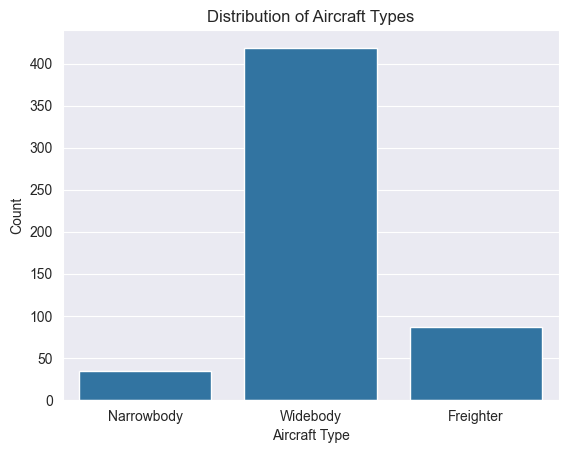

Imbalance Ratio (Narrowbody:Widebody) = 34:419 = 0.081145584725537


In [37]:
# TODO classify based on aircaft type, frequency throughout the year plotting trends
# also cluster type wrt routes, cluster types wrt partner, aw
import seaborn as sns
import matplotlib.pyplot as plt
import polars as pl

sns.set_style("darkgrid")
# bar chart of aircraft type
plt.figure()
sns.countplot(data=df_shipping, x="Aircraft Type")
plt.title("Distribution of Aircraft Types")
plt.ylabel("Count")
plt.show()

# Imbalance ratio of aircraft type
aircraft_counts = df_shipping["Aircraft Type"].value_counts()

# Convert to dictionary for easy lookup
counts_dict = dict(
    zip(
        aircraft_counts["Aircraft Type"],
        aircraft_counts["count"]
    )
)

narrowbody = counts_dict.get("Narrowbody", 0)
widebody = counts_dict.get("Widebody", 0)

print(f"Imbalance Ratio (Narrowbody:Widebody) = {narrowbody}:{widebody} = {narrowbody/widebody if widebody > 0 else 'Infinity'}")


In [38]:
top_n = 7

top_origins = (
    df_shipping.group_by(["Origin", "Aircraft Type"])
    .len()
    .sort("len", descending=True)
    .group_by("Aircraft Type")
    .head(top_n)
    .select("Origin")
    .unique()
    .to_series()
    .to_list()
)

top_destinations = (
    df_shipping.group_by(["Destination", "Aircraft Type"])
    .len()
    .sort("len", descending=True)
    .group_by("Aircraft Type")
    .head(top_n)
    .select("Destination")
    .unique()
    .to_series()
    .to_list()
)

print(f"Top {top_n} Origins: {top_origins}")
print(f"Top {top_n} Destinations: {top_destinations}")

Top 7 Origins: ['SHJ', 'LHR', 'BNE', 'CDG', 'JFK', 'PTY', 'IAD', 'MIA', 'EWR', 'DXB', 'YUL', 'YYZ', 'ORD', 'AMS']
Top 7 Destinations: ['BGI', 'JUB', 'PZU', 'WAW', 'MUC', 'BEY', 'AMM', 'PAP', 'GND', 'SVD', 'OGG', 'FCO', 'VIE', 'NDJ', 'CGN', 'EBL']


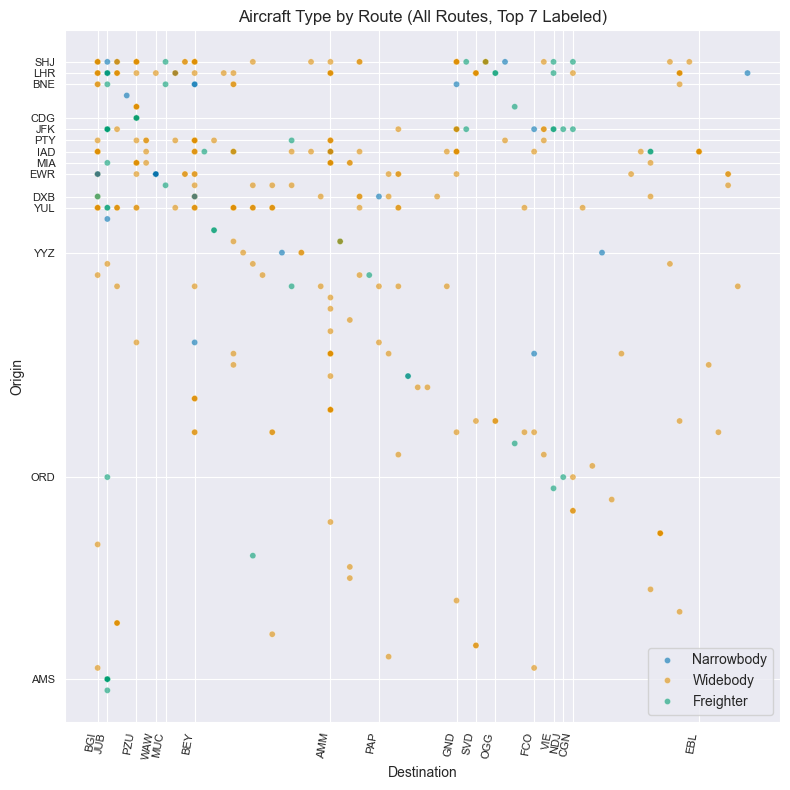

In [39]:
plt.figure(figsize=(8, 8))
colors = sns.color_palette("colorblind", n_colors=df_shipping["Aircraft Type"].n_unique())

plot = sns.scatterplot(
    data=df_shipping, 
    x="Destination", 
    y="Origin", 
    hue="Aircraft Type",
    s=20,
    alpha=0.6,
    palette=colors
)

plot.set_xticks([i for i, label in enumerate(plot.get_xticklabels()) if label.get_text() in top_destinations])
plot.set_xticklabels(top_destinations, rotation=80, ha="right", fontsize=8)


plot.set_yticks([i for i, label in enumerate(plot.get_yticklabels()) if label.get_text() in top_origins])
plot.set_yticklabels(top_origins, fontsize=8)

plt.title(f"Aircraft Type by Route (All Routes, Top {top_n} Labeled)")
plt.legend()#bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

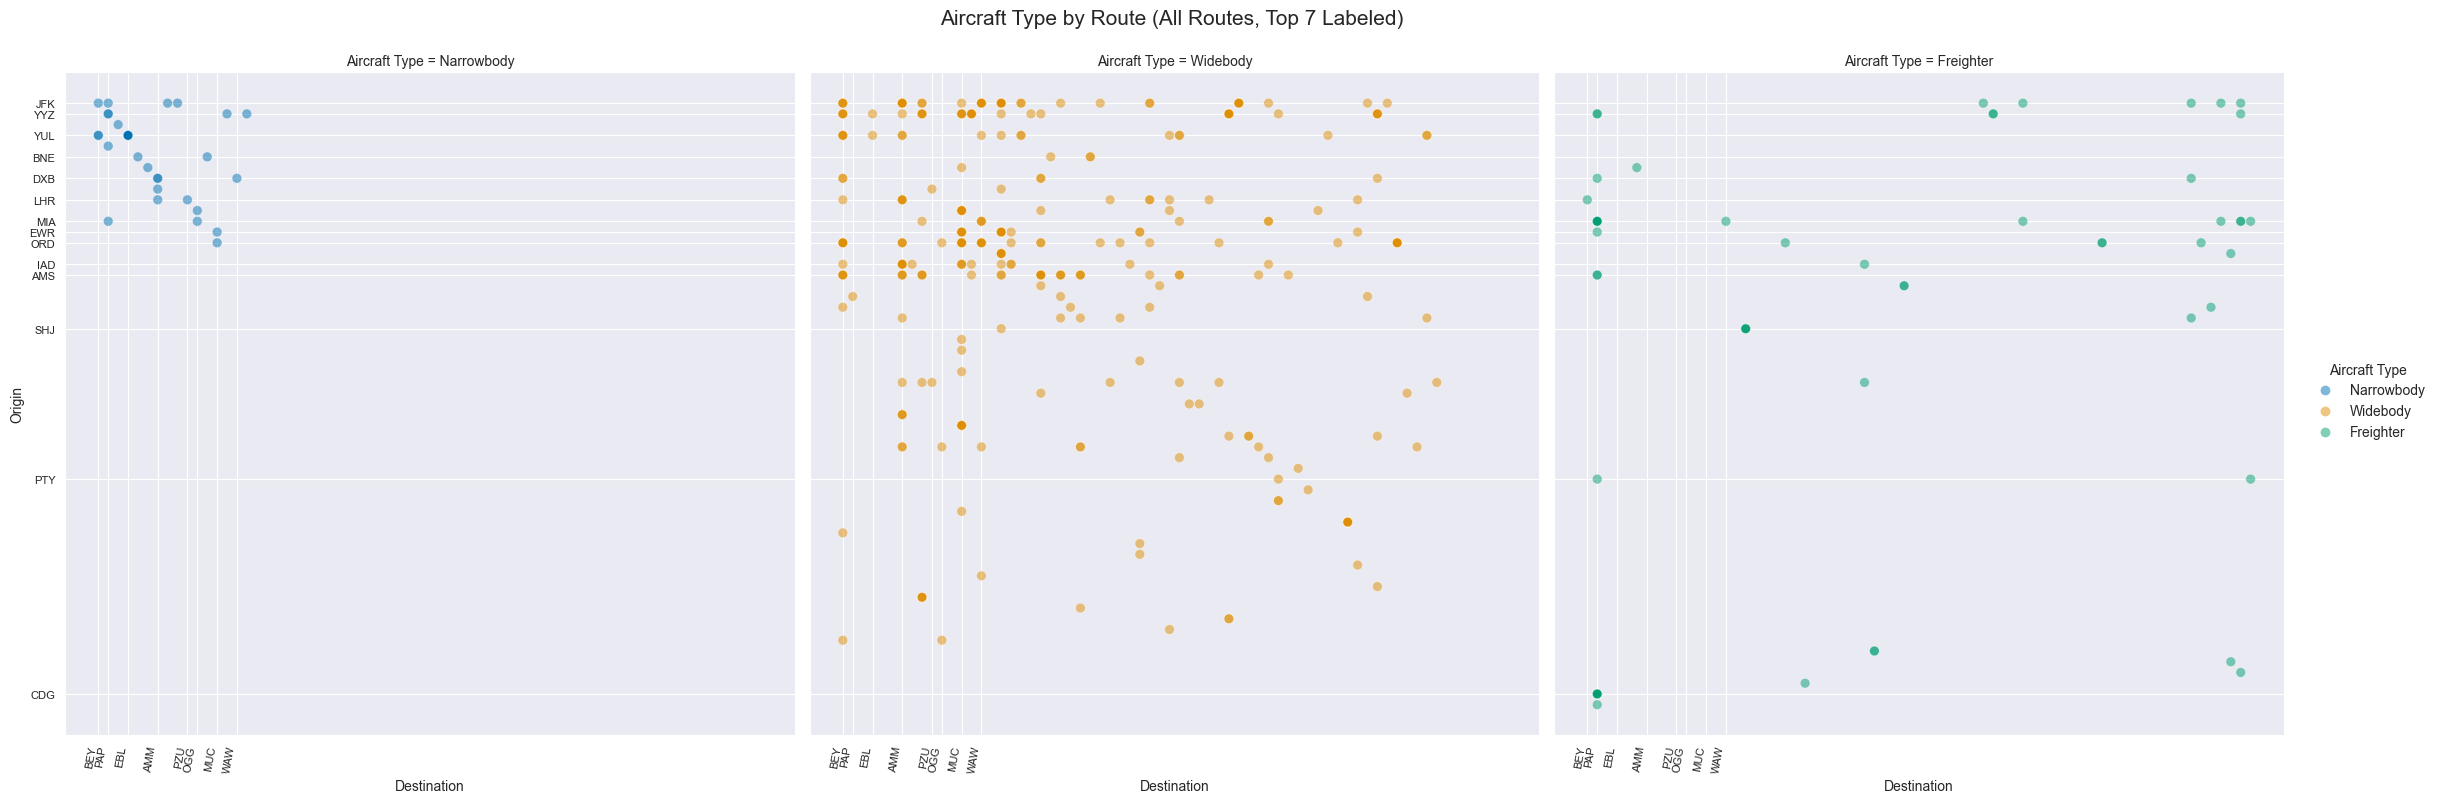

In [40]:
g = sns.relplot(
    data=df_shipping, # Using the original full dataframe
    x="Destination", 
    y="Origin", 
    col="Aircraft Type", 
    col_wrap=3, 
    height=8, 
    aspect=1, 
    s=50,             # Smaller dots for dense data
    alpha=0.5, 
    kind="scatter",
    hue="Aircraft Type",
    palette=colors
)

# Iterate through axes to clean up the text wall
for i, ax in enumerate(g.axes.flat):
    ax.tick_params(axis='both', which='major', labelsize=6)
    ax.set_xticks([i for i, label in enumerate(ax.get_xticklabels()) if label.get_text() in top_destinations])
    plt.setp(ax.get_xticklabels(), rotation=80, ha="right", fontsize=8) 

    if i % 3 == 0:  # Only rotate X labels for the first column to save space
        ax.set_yticks([i for i, label in enumerate(ax.get_yticklabels()) if label.get_text() in top_origins])
        plt.setp(ax.get_yticklabels(), fontsize=8)

plt.subplots_adjust(top=0.9)
plt.suptitle(f"Aircraft Type by Route (All Routes, Top {top_n} Labeled)", fontsize=15)
plt.show()

In [41]:
df_shipping

NGO ID,Shipment ID,Received,Deadline Date,Origin,Destination,Cargo Ready Date,Depart,Arrive,Forwarder,AWB #,Airlink Partner,Aircraft Type,AW (kg),CBM,Pallets,Incoterms,Last-mile Requested,Consignee,NGO Payments,Commercial Cost for First Mile,Commercial Cost for Long-Haul,Commercial Cost for Last Mile,Total Value Delivered,GIK Value Delivered by Airlink (=Value delivered - NGO payments - Invoiced),Airline,Valuation Source,Year
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i32
"""NP187""","""24-0294""","""2024-08-28 00:00:00""","""2024-08-30""","""JFK""","""BEY""","""2024-08-01 00:00:00""","""2025-02-12 00:00:00""","""2025-02-14 00:00:00""","""PWS""","""157-02144730""","""Qatar Airways""","""Narrowbody""","""262""","""3.272""","""4""","""DAT""","""No""","""YMCA of Lebanon Delta Center, …","""""","""402.84""","""2044""","""""","""2446.84""","""2446.84""","""Qatar Airways""","""Commercial Rate""",2025
"""NP015""","""24-0315""","""2024-10-02 00:00:00""","""2024-10-10""","""YYZ""","""PAP""","""2024-10-03 00:00:00""","""2025-02-07 00:00:00""","""2025-02-20 00:00:00""","""PWS""","""001-86266633""","""American Airlines""","""Narrowbody""","""264.45""","""1.887""","""3""","""CPT""","""Yes""","""CENTRE MEDICAL BERACA - Dr. Al…","""""","""533.66""","""4690""","""""","""5223.66""","""4690""","""American Airlines""","""Online Calculator""",2025
"""NP187""","""24-0337""","""2024-12-10 00:00:00""","""2024-12-10""","""DXB""","""BEY""","""2024-12-16 00:00:00""","""2025-01-05 00:00:00""","""2025-01-05 00:00:00""","""PWS""","""076-43047911""","""Commercial""","""Widebody""","""704""","""2.688""","""2""","""DAT""","""No""","""YMCA of Lebanon, Delta Center,…","""0""","""0""","""3790""","""0""","""3790""","""0""","""Commercial""","""Commercial Rate""",2025
"""NP015""","""24-0341""","""2024-12-19 00:00:00""","""2025-01-10""","""YYZ""","""TLV""","""2025-01-02 00:00:00""","""2025-02-13 00:00:00""","""2025-02-15 00:00:00""","""PWS""","""700-74270232""","""Commercial""","""Widebody""","""1583""","""5.664""","""4""","""CPT""","""No""","""ANERA 13 NABLUS ROAD SHE…","""""","""1638.66""","""8801""","""""","""10439.66""","""0""","""Commercial""","""Commercial Rate""",2025
"""NP269""","""24-0342""","""2024-12-24 00:00:00""","""2024-12-26""","""JAX""","""VLI""","""2024-12-24 00:00:00""","""2025-01-13 00:00:00""","""2025-01-17 00:00:00""","""PWS""","""260-40755245""","""United Airlines, Fiji Airways""","""Narrowbody""","""108.42""","""1.0069""","""1""","""CPT""","""No""","""Peter Judge Vanuatu Business R…","""0""","""1999.43""","""3158""","""0""","""5157.43""","""3158""","""United Airlines, Fiji Airways""","""Online Calculator""",2025
"""NP285,NP127""","""24-0344""","""2024-12-30 00:00:00""","""2025-01-06""","""LGG""","""NDJ""","""2024-12-30 00:00:00""","""2025-01-24 00:00:00""","""2025-02-09 00:00:00""","""SEKO""","""071-54528585""","""Commercial""","""Widebody""","""1886""","""7.727""","""6""","""DAP""","""Yes""","""INTERSOS Sudan Geneina Office …","""0""","""1378.69""","""9851.24""","""15605.89""","""26835.82""","""-17186.13""","""Commercial""","""Commercial Rate""",2025
"""NP224""","""24-0345""","""2024-12-30 00:00:00""","""2025-01-06""","""SHJ""","""NDJ""","""2025-01-06 00:00:00""","""2025-01-25 00:00:00""","""2025-02-12 00:00:00""","""SEKO""","""071-55544366""","""Commercial""","""Freighter""","""16474""","""154.67""","""116""","""DAP""","""Yes""","""NTERSOS SUDAN Binay Basyal H…","""0""","""9166.65""","""148229.25""","""185150.98""","""342546.88""","""13750""","""Commercial""","""Commercial Rate""",2025
"""NP206""","""24-0360""","""2024-12-13 00:00:00""","""2024-11-25""","""MIA""","""PAP""","""""","""2025-02-25 00:00:00""","""2025-03-11 00:00:00""","""PWS""","""810-43041515""","""Amerijet""","""Freighter""","""127.913""","""0.666""","""1""","""DAP""",null,"""Parole and Action""","""""","""1211.64""","""384""","""""","""1595.64""","""0""","""Amerijet""","""Commercial Rate""",2025
…,…,…,…,…,…,…,…

In [42]:
import polars as pl
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

# --- CONFIGURATION ---
target = "Aircraft Type"
# List ALL candidate columns you have
cat_features = ["NGO ID", 'Origin', 'Destination', 'Forwarder', 'Airlink Partner', 'Airline', "Route"]
num_features = ["AW (kg)", "Pallets", 'Commercial Cost for First Mile', 'Commercial Cost for Long-Haul', 'Commercial Cost for Last Mile', 'Total Value Delivered', 'GIK Value Delivered by Airlink (=Value delivered - NGO payments - Invoiced)', 
                'distance', 'Origin_Lat', 'Origin_Lon', 'Destination_Lat', 'Destination_Lon']

# Convert to Pandas for Scikit-Learn (Polars is not yet natively supported in sklearn)
# Drop rows with nulls in these columns to prevent errors
# combine origin destination into one column
df_od = df_dist.with_columns(
    pl.concat_str([pl.col("Origin"), pl.col("Destination")], separator="_").alias("Route")
)
df_ml = (
    df_od
    .select(cat_features + num_features + [target])
    .with_columns(pl.col(pl.String).replace("", None))
    .drop_nulls()
    .to_pandas()
)


In [43]:
df_ml

,NGO ID,Origin,Destination,Forwarder,Airlink Partner,Airline,Route,AW (kg),Pallets,Commercial Cost for First Mile,Commercial Cost for Long-Haul,Commercial Cost for Last Mile,Total Value Delivered,GIK Value Delivered by Airlink (=Value delivered - NGO payments - Invoiced),distance,Origin_Lat,Origin_Lon,Destination_Lat,Destination_Lon,Aircraft Type
0,NP187,DXB,BEY,PWS,Commercial,Commercial,DXB_BEY,704,2,0,3790,0,3790,0,2140.680300,25.25280,55.36440,33.82090,35.48840,Widebody
1,NP269,JAX,VLI,PWS,"United Airlines, Fiji Airways","United Airlines, Fiji Airways",JAX_VLI,108.42,1,1999.43,3158,0,5157.43,3158,12874.255425,30.49405,-81.68785,-17.69930,168.32001,Narrowbody
2,"NP285,NP127",LGG,NDJ,SEKO,Commercial,Commercial,LGG_NDJ,1886,6,1378.69,9851.24,15605.89,26835.82,-17186.13,4369.345802,50.63740,5.44322,12.13370,15.03400,Widebody
3,NP224,SHJ,NDJ,SEKO,Commercial,Commercial,SHJ_NDJ,16474,116,9166.65,148229.25,185150.98,342546.88,13750,4487.303181,25.32860,55.51720,12.13370,15.03400,Freighter
4,NP180,IAD,LAX,SEKO,United Airlines,United Airlines,IAD_LAX,184.16,2,1785,6435,555,8775,6322.92,3670.590799,38.90000,-77.50000,33.94250,-118.40805,Widebody
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,NP112,JFK,DAC,SEKO,Cathay Pacific,Cathay Pacific,JFK_DAC,1098,9,820.08,4776.3,0,5596.38,4776.3,12660.450745,40.63993,-73.77869,23.84335,90.39778,Widebody
146,NP002,DFW,OGG,SEKO,American Airlines,American Airlines,DFW_OGG,17980.56,45,4450,25352.59,7013.34,36815.93,25352.59,5962.366069,32.89723,-97.03769,20.89865,-156.43046,Widebody
147,NP127,AMS,KBL,PWS,"Kam Air, Qatar Airways","Kam Air, Qatar Airways",AMS_KBL,658.1,2,2105.01,3957.96,0,6062.97,2040.96,5363.136191,52.30860,4.76389,34.56590,69.21230,Widebody
148,NP015,YYZ,CGN,PWS,CargoJet,CargoJet,YYZ_CGN,869,6,550,5139.989,4500.021,10190.01,5140,6210.194833,43.67720,-79.63060,50.86590,7.14274,Freighter


C:\Users\mborrero\AppData\Local\Temp\ipykernel_60036\1675193051.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = pd.to_numeric(X[col], errors="coerce")
C:\Users\mborrero\AppData\Local\Temp\ipykernel_60036\1675193051.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_impact, x="Impact Score", y="Variable", palette="viridis")


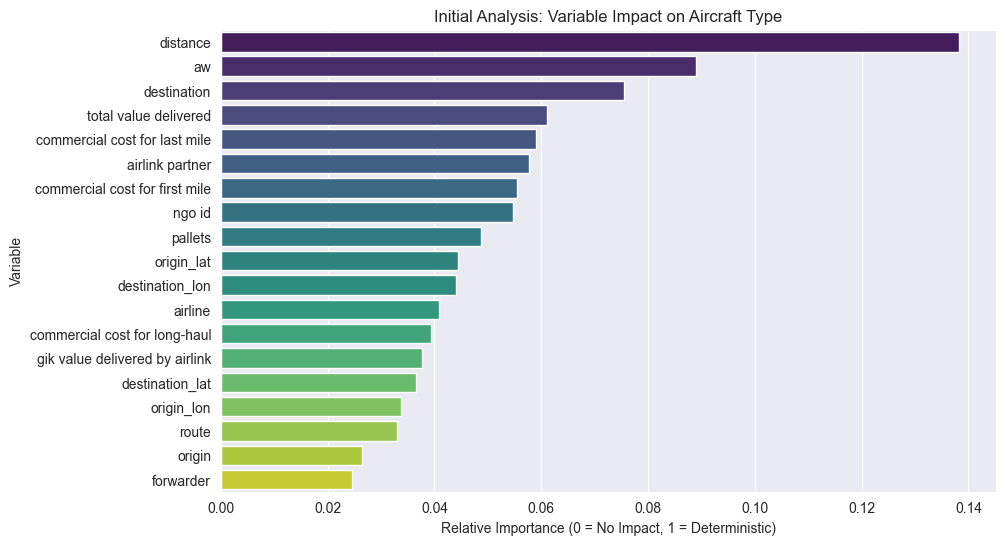

Top Drivers:
                         Variable  Impact Score
14                       distance      0.138226
7                              aw      0.088916
2                     destination      0.075464
12          total value delivered      0.061066
11  commercial cost for last mile      0.059076


In [44]:

X = df_ml[cat_features + num_features]
y = df_ml[target]

# 2. Build the Analyzer
# OrdinalEncoder turns text strings into numbers (0, 1, 2) so the model can read them
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_features),
        ('num', 'passthrough', num_features)
    ]
)

for col in num_features:
    X[col] = pd.to_numeric(X[col], errors="coerce")


# Use a Random Forest because it doesn't care about outliers or distribution shapes
rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1))
])

# 3. Fit and Calculate Importance
rf.fit(X, y)

# We extract the standard "Gini Importance"
importances = rf.named_steps['model'].feature_importances_
# do strs (each feature) up to first (
feature_names = [f.split('(')[0].strip().lower() for f in cat_features + num_features]

# Create the Ranking DataFrame
df_impact = pd.DataFrame({
    'Variable': feature_names,
    'Impact Score': importances
}).sort_values(by='Impact Score', ascending=False)

# --- VISUALIZE THE RANKING ---
plt.figure(figsize=(10, 6))
sns.barplot(data=df_impact, x="Impact Score", y="Variable", palette="viridis")
plt.title("Initial Analysis: Variable Impact on Aircraft Type")
plt.xlabel("Relative Importance (0 = No Impact, 1 = Deterministic)")
plt.show()

print("Top Drivers:")
print(df_impact.head(5))

X_sample shape: (50, 19)
SHAP values shape: (50, 19, 3)
Classes: ['Freighter' 'Narrowbody' 'Widebody']


C:\Users\mborrero\AppData\Local\Temp\ipykernel_60036\2913064544.py:50: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


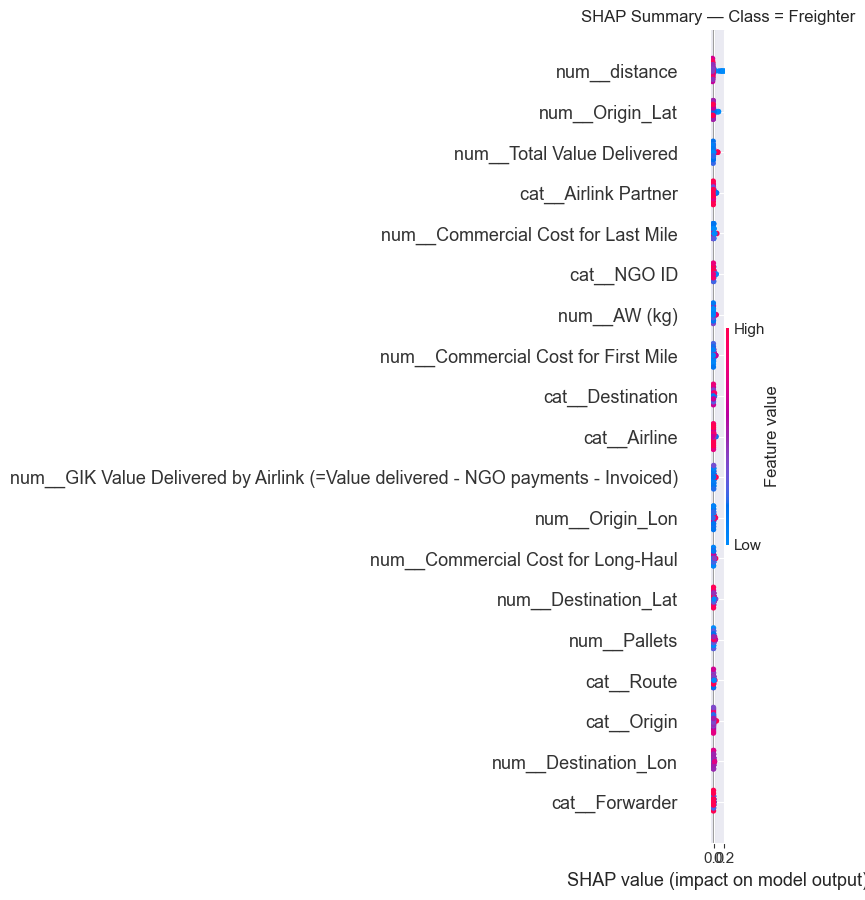

C:\Users\mborrero\AppData\Local\Temp\ipykernel_60036\2913064544.py:50: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


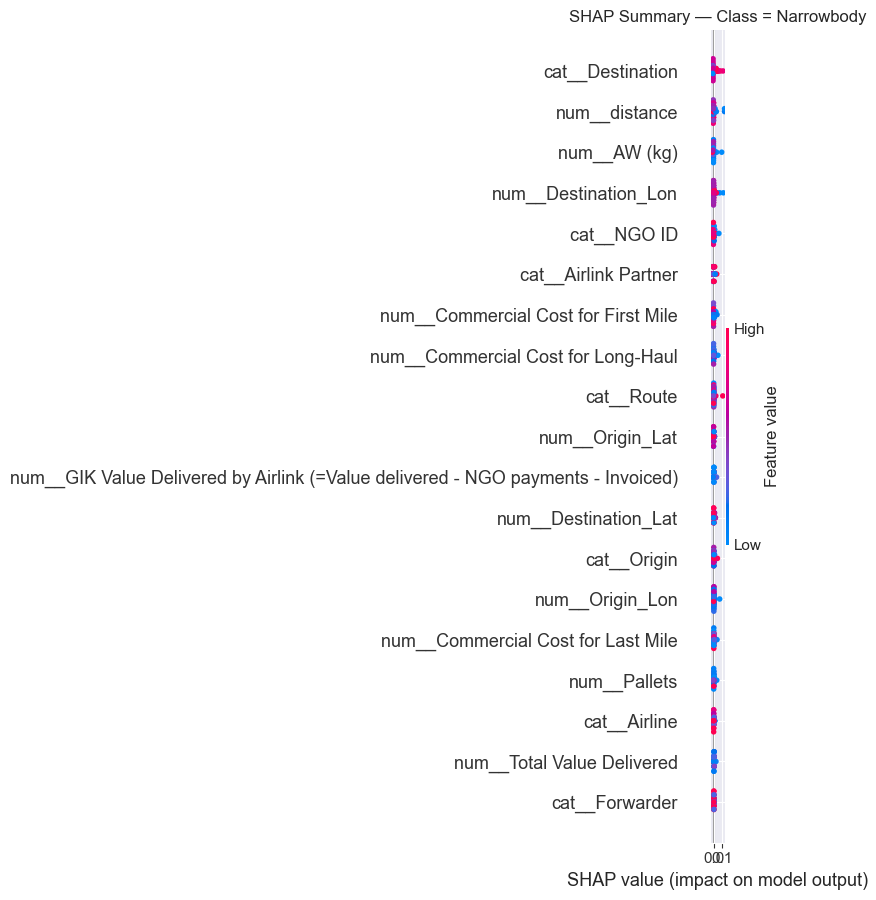

C:\Users\mborrero\AppData\Local\Temp\ipykernel_60036\2913064544.py:50: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


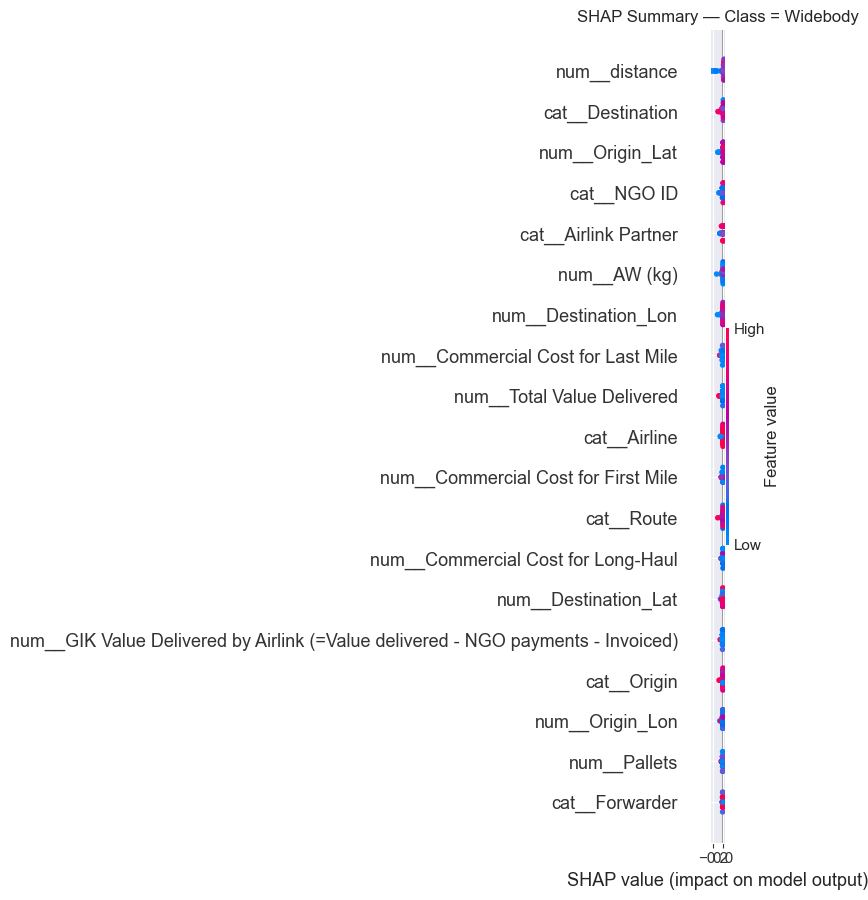

In [45]:
import numpy as np
import shap
import matplotlib.pyplot as plt

# ----------------------------------------------------
# 1. Pull trained pieces from your pipeline
# ----------------------------------------------------
model = rf.named_steps["model"]
preprocessor = rf.named_steps["preprocessor"]

# ----------------------------------------------------
# 2. Transform X exactly how model sees it
# ----------------------------------------------------
X_transformed = preprocessor.transform(X)

# Convert sparse → dense if needed
if hasattr(X_transformed, "toarray"):
    X_transformed = X_transformed.toarray()

# Feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# ----------------------------------------------------
# 3. Subsample rows for speed
# ----------------------------------------------------
np.random.seed(0)
idx = np.random.choice(X_transformed.shape[0], 50, replace=False)
X_sample = X_transformed[idx]

print("X_sample shape:", X_sample.shape)

# ----------------------------------------------------
# 4. Build SHAP explainer
# ----------------------------------------------------
explainer = shap.TreeExplainer(model)

# ----------------------------------------------------
# 5. Compute SHAP values
# ----------------------------------------------------
shap_values = explainer(X_sample)

print("SHAP values shape:", shap_values.values.shape)
print("Classes:", model.classes_)

# ----------------------------------------------------
# 6. One SHAP summary plot per class
# ----------------------------------------------------
for i, cls in enumerate(model.classes_):

    shap.summary_plot(
        shap_values.values[:, :, i],   # samples × features
        X_sample,
        feature_names=feature_names,
        show=False
    )

    plt.title(f"SHAP Summary — Class = {cls}")
    plt.tight_layout()
    plt.show()


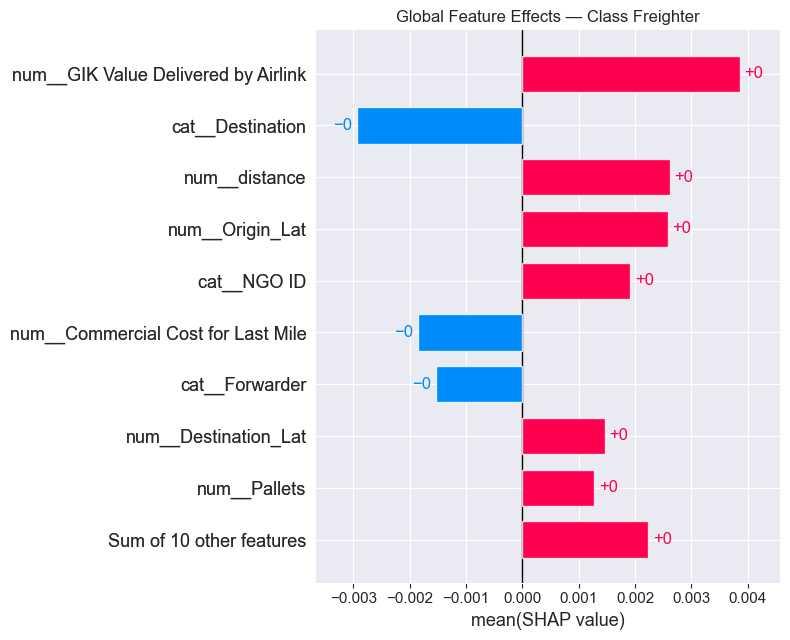

In [46]:
import numpy as np
import shap
import matplotlib.pyplot as plt

# ----------------------------------------------------
# 1. Pull trained pieces
# ----------------------------------------------------
model = rf.named_steps["model"]
preprocessor = rf.named_steps["preprocessor"]

# ----------------------------------------------------
# 2. Transform X
# ----------------------------------------------------
X_transformed = preprocessor.transform(X)

if hasattr(X_transformed, "toarray"):
    X_transformed = X_transformed.toarray()

# Short feature names
feature_names = [
    f.split("(")[0].strip()
    for f in preprocessor.get_feature_names_out()
]

# ----------------------------------------------------
# 3. Subsample
# ----------------------------------------------------
np.random.seed(0)
idx = np.random.choice(X_transformed.shape[0], 50, replace=False)
X_sample = X_transformed[idx]

# ----------------------------------------------------
# 4. SHAP
# ----------------------------------------------------
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_sample)

# ----------------------------------------------------
# 5. Choose class
# ----------------------------------------------------
class_idx = 0

# ----------------------------------------------------
# 6. Build Explanation w/ feature names
# ----------------------------------------------------
exp = shap.Explanation(
    values=shap_values.values[:, :, class_idx],
    data=X_sample,
    feature_names=feature_names
)

# ----------------------------------------------------
# 7. Signed global bar plot
# ----------------------------------------------------
shap.plots.bar(
    exp.mean(0),     # SIGNED mean (not abs)
    show=False
)

plt.title(f"Global Feature Effects — Class {model.classes_[class_idx]}")
plt.tight_layout()
plt.show()


In [47]:
# LDA implementation


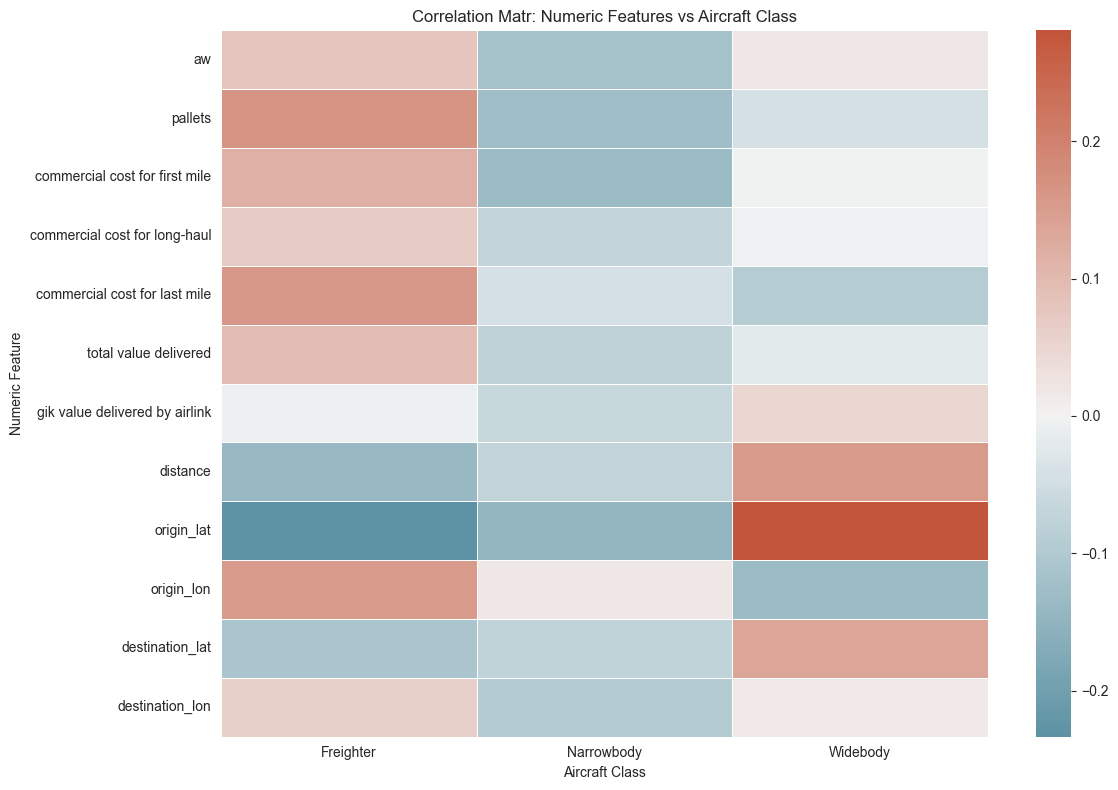

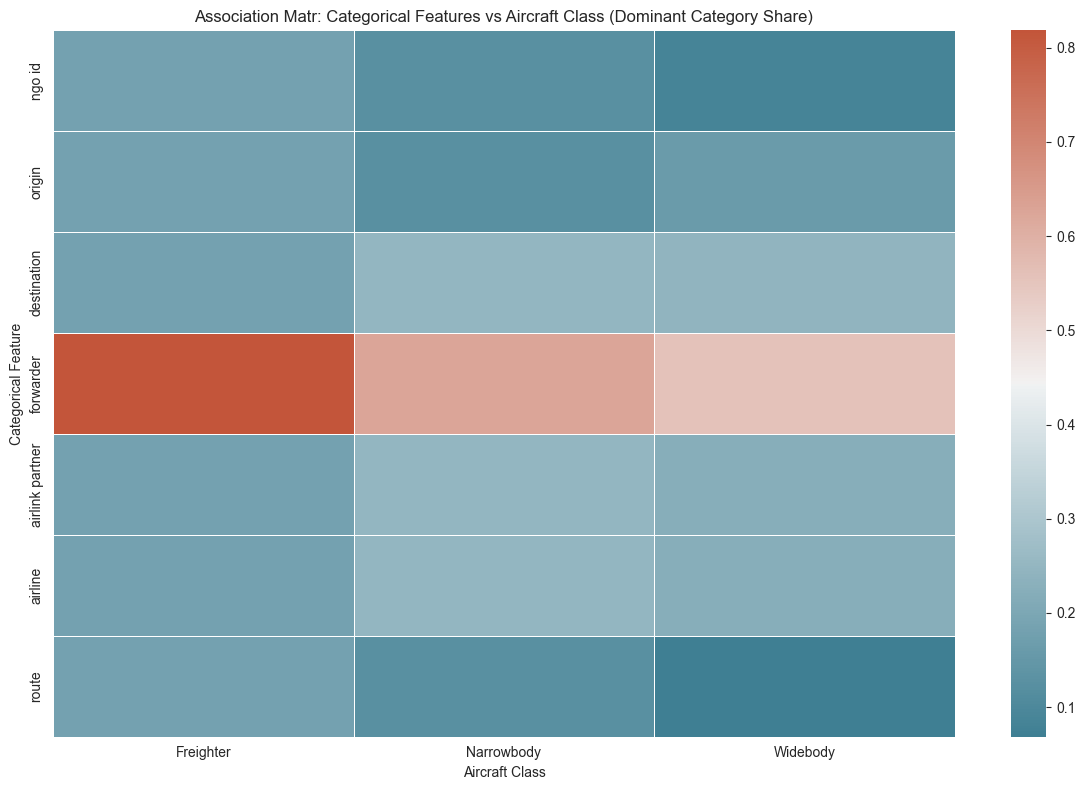

In [48]:
short_num_names = [f.split('(')[0].strip().lower() for f in num_features]
short_cat_names = [f.split('(')[0].strip().lower() for f in cat_features]

classes = sorted(df_ml[target].unique())

corr_mat = pd.DataFrame(index=short_num_names, columns=classes)

for cls in classes:
    y_bin = (df_ml[target] == cls).astype(int)

    for f, short_name in zip(num_features, short_num_names):
        x = pd.to_numeric(df_ml[f], errors="coerce")
        corr_mat.loc[short_name, cls] = x.corr(y_bin)

corr_mat = corr_mat.astype(float)

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_mat,
    cmap=sns.diverging_palette(220, 20, as_cmap=True),
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matr: Numeric Features vs Aircraft Class")
plt.xlabel("Aircraft Class")
plt.ylabel("Numeric Feature")
plt.tight_layout()
plt.show()

# Association matr
assoc_mat = pd.DataFrame(index=short_cat_names, columns=classes)

for cls in classes:
    subset = df_ml[df_ml[target] == cls]

    for f, short_name in zip(cat_features, short_cat_names):
        if subset[f].isna().all():
            assoc_mat.loc[short_name, cls] = np.nan
        else:
            freq = subset[f].value_counts(normalize=True)
            assoc_mat.loc[short_name, cls] = freq.iloc[0]

assoc_mat = assoc_mat.astype(float)

plt.figure(figsize=(12, 8))
sns.heatmap(
    assoc_mat,
    cmap=sns.diverging_palette(220, 20, as_cmap=True),
    linewidths=0.5
)

plt.title("Association Matr: Categorical Features vs Aircraft Class (Dominant Category Share)")
plt.xlabel("Aircraft Class")
plt.ylabel("Categorical Feature")
plt.tight_layout()
plt.show()



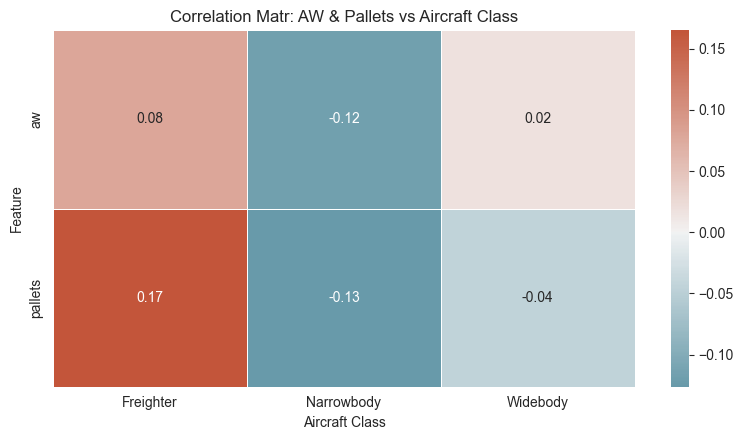

In [49]:
# Correlation matrix: AW and Pallets vs aircraft class
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

target_col = target if "target" in globals() else "Aircraft Type"
classes = ["Freighter", "Narrowbody", "Widebody"]
feature_cols = ["AW (kg)", "Pallets"]
feature_labels = ["aw", "pallets"]

if "df_ml" not in globals():
    raise ValueError("df_ml is not available. Run the data prep cells first.")

plot_df = df_ml[[*feature_cols, target_col]].copy()
plot_df[feature_cols[0]] = pd.to_numeric(plot_df[feature_cols[0]], errors="coerce")
plot_df[feature_cols[1]] = pd.to_numeric(plot_df[feature_cols[1]], errors="coerce")
plot_df[target_col] = plot_df[target_col].astype(str).str.strip().str.title()
plot_df = plot_df.dropna(subset=[*feature_cols, target_col])

corr_mat_small = pd.DataFrame(index=feature_labels, columns=classes, dtype=float)

for cls in classes:
    y_bin = (plot_df[target_col] == cls).astype(int)
    for raw_col, short_name in zip(feature_cols, feature_labels):
        corr_mat_small.loc[short_name, cls] = plot_df[raw_col].corr(y_bin)

plt.figure(figsize=(8, 4.5))
sns.heatmap(
    corr_mat_small,
    cmap=sns.diverging_palette(220, 20, as_cmap=True),
    center=0,
    linewidths=0.5,
    annot=True,
    fmt=".2f",
)
plt.title("Correlation Matr: AW & Pallets vs Aircraft Class")
plt.xlabel("Aircraft Class")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [50]:
# Mean AW and pallet count by aircraft class
import pandas as pd

target_col = target if "target" in globals() else "Aircraft Type"

if "df_ml" not in globals():
    raise ValueError("df_ml is not available. Run the data prep cells first.")

summary_means = (
    df_ml[[target_col, "AW (kg)", "Pallets"]]
    .assign(
        **{
            "AW (kg)": pd.to_numeric(df_ml["AW (kg)"], errors="coerce"),
            "Pallets": pd.to_numeric(df_ml["Pallets"], errors="coerce"),
        }
    )
    .dropna(subset=[target_col, "AW (kg)", "Pallets"])
    .groupby(target_col, as_index=False)[["AW (kg)", "Pallets"]]
    .mean()
    .rename(columns={"AW (kg)": "mean_aw_kg", "Pallets": "mean_pallets"})
    .sort_values(target_col)
    .round({"mean_aw_kg": 2, "mean_pallets": 2})
)

print("Mean AW and pallet number by aircraft class:")
display(summary_means)

Mean AW and pallet number by aircraft class:


,Aircraft Type,mean_aw_kg,mean_pallets
0,Freighter,6957.57,23.73
1,Narrowbody,1335.52,5.38
2,Widebody,4973.87,13.82


In [51]:
# Count repeated routes by Origin and Destination
import polars as pl

if "df_shipping" not in globals():
    raise ValueError("df_shipping is not available. Run the shipping-data load cell first.")

route_counts = (
    df_shipping
    .group_by(["Origin", "Destination"])
    .len()
    .sort("len", descending=True)
)

repeated_routes = route_counts.filter(pl.col("len") > 1)

total_repeated_rows = int((repeated_routes["len"] - 1).sum()) if repeated_routes.height > 0 else 0
repeated_route_pairs = repeated_routes.height

print(f"Repeated Origin/Destination route pairs: {repeated_route_pairs}")
print(f"Repeated entries beyond the first occurrence: {total_repeated_rows}")

display(repeated_routes)

Repeated Origin/Destination route pairs: 71
Repeated entries beyond the first occurrence: 335


Origin,Destination,len
str,str,u32
"""ORD""","""FCO""",45
"""MIA""","""PAP""",31
"""IAD""","""AMM""",31
"""YYZ""","""VIE""",31
"""ORD""","""MUC""",11
"""LHE""","""UAB""",11
"""JFK""","""AMM""",10
"""CDG""","""PAP""",10
…,…,…


In [52]:
# Count repeated entries by Airlink Partner and route pair
import polars as pl

if "df_shipping" not in globals():
    raise ValueError("df_shipping is not available. Run the shipping-data load cell first.")

pair_counts = (
    df_shipping
    .group_by(["Airlink Partner", "Origin", "Destination"])
    .len()
    .sort("len", descending=True)
)

repeated_pairs = pair_counts.filter(pl.col("len") > 1)

total_repeated_rows = int((repeated_pairs["len"] - 1).sum()) if repeated_pairs.height > 0 else 0
repeated_pair_count = repeated_pairs.height

print(f"Repeated Airlink Partner + route pairs: {repeated_pair_count}")
print(f"Repeated entries beyond the first occurrence: {total_repeated_rows}")

display(repeated_pairs)

Repeated Airlink Partner + route pairs: 69
Repeated entries beyond the first occurrence: 300


Airlink Partner,Origin,Destination,len
str,str,str,u32
"""American Airlines""","""ORD""","""FCO""",45
"""United Airlines""","""IAD""","""AMM""",31
"""Air Canada""","""YYZ""","""VIE""",31
"""Amerijet""","""MIA""","""PAP""",26
"""United Airlines""","""ORD""","""MUC""",11
"""Turkish Airlines""","""LHE""","""UAB""",11
"""Amerijet""","""CDG""","""PAP""",10
"""United Airlines, Charter""","""EWR""","""NDJ""",9
…,…,…,…


In [56]:
# Price per mile per airline (with spread metrics)
import polars as pl

# Prefer a dataframe that already has distance available
source_df = None
required_base = {"Airline", "Commercial Cost for Long-Haul", "AW (kg)", "Pallets"}
for name in ["df_dist", "df_shipping"]:
    if name in globals():
        candidate = globals()[name]
        if isinstance(candidate, pl.DataFrame):
            has_distance = ("distance" in candidate.columns) or ("Distance" in candidate.columns)
            if required_base.issubset(set(candidate.columns)) and has_distance:
                source_df = candidate
                break

if source_df is None:
    raise ValueError("Could not find a dataframe with Airline, Commercial Cost for Long-Haul, AW (kg), Pallets, and distance columns.")

distance_col = "distance" if "distance" in source_df.columns else "Distance"
cost_col = "Commercial Cost for Long-Haul"
weight_col = "AW (kg)"
pallet_col = "Pallets"

airline_ppm = (
    source_df
    .select(["Airline", cost_col, distance_col, weight_col, pallet_col])
    .with_columns([
        pl.col("Airline").cast(pl.Utf8),
        pl.col(cost_col).cast(pl.Utf8).str.replace_all(",", "").cast(pl.Float64, strict=False).alias("long_haul_cost"),
        pl.col(distance_col).cast(pl.Utf8).str.replace_all(",", "").cast(pl.Float64, strict=False).alias("distance_miles"),
        pl.col(weight_col).cast(pl.Utf8).str.replace_all(",", "").cast(pl.Float64, strict=False).alias("shipment_weight_kg"),
        pl.col(pallet_col).cast(pl.Utf8).str.replace_all(",", "").cast(pl.Float64, strict=False).alias("pallet_count"),
    ])
    .filter(
        pl.col("Airline").is_not_null()
        & pl.col("long_haul_cost").is_not_null()
        & pl.col("distance_miles").is_not_null()
        & (pl.col("long_haul_cost") > 0)
        & (pl.col("distance_miles") > 0)
    )
    .with_columns(pl.col("Airline").str.split(",").alias("airline_name"))
    .explode("airline_name")
    .with_columns(pl.col("airline_name").str.strip_chars())
    .filter(pl.col("airline_name") != "")
    .with_columns([
        (pl.col("long_haul_cost") / pl.col("distance_miles")).alias("price_per_mile"),
        pl.when((pl.col("shipment_weight_kg") > 0))
          .then(pl.col("long_haul_cost") / (pl.col("distance_miles") * pl.col("shipment_weight_kg")))
          .otherwise(None)
          .alias("price_per_mile_per_kg"),
        pl.when((pl.col("pallet_count") > 0))
          .then(pl.col("long_haul_cost") / (pl.col("distance_miles") * pl.col("pallet_count")))
          .otherwise(None)
          .alias("price_per_mile_per_pallet"),
    ])
    .group_by("airline_name")
    .agg([
        pl.len().alias("n_shipments"),

        # Base price-per-mile
        pl.col("price_per_mile").mean().alias("mean_price_per_mile"),
        pl.col("price_per_mile").median().alias("median_price_per_mile"),
        pl.col("price_per_mile").std().alias("std_price_per_mile"),
        pl.col("price_per_mile").quantile(0.25).alias("q25_price_per_mile"),
        pl.col("price_per_mile").quantile(0.75).alias("q75_price_per_mile"),
        pl.col("price_per_mile").min().alias("min_price_per_mile"),
        pl.col("price_per_mile").max().alias("max_price_per_mile"),

        # Scaled by shipment weight
        pl.col("price_per_mile_per_kg").mean().alias("mean_price_per_mile_per_kg"),
        pl.col("price_per_mile_per_kg").median().alias("median_price_per_mile_per_kg"),
        pl.col("price_per_mile_per_kg").std().alias("std_price_per_mile_per_kg"),
        pl.col("price_per_mile_per_kg").quantile(0.25).alias("q25_price_per_mile_per_kg"),
        pl.col("price_per_mile_per_kg").quantile(0.75).alias("q75_price_per_mile_per_kg"),
        pl.col("price_per_mile_per_kg").min().alias("min_price_per_mile_per_kg"),
        pl.col("price_per_mile_per_kg").max().alias("max_price_per_mile_per_kg"),

        # Scaled by pallet count
        pl.col("price_per_mile_per_pallet").mean().alias("mean_price_per_mile_per_pallet"),
        pl.col("price_per_mile_per_pallet").median().alias("median_price_per_mile_per_pallet"),
        pl.col("price_per_mile_per_pallet").std().alias("std_price_per_mile_per_pallet"),
        pl.col("price_per_mile_per_pallet").quantile(0.25).alias("q25_price_per_mile_per_pallet"),
        pl.col("price_per_mile_per_pallet").quantile(0.75).alias("q75_price_per_mile_per_pallet"),
        pl.col("price_per_mile_per_pallet").min().alias("min_price_per_mile_per_pallet"),
        pl.col("price_per_mile_per_pallet").max().alias("max_price_per_mile_per_pallet"),
    ])
    .with_columns([
        (pl.col("q75_price_per_mile") - pl.col("q25_price_per_mile")).alias("spread_iqr"),
        (pl.col("max_price_per_mile") - pl.col("min_price_per_mile")).alias("spread_range"),

        (pl.col("q75_price_per_mile_per_kg") - pl.col("q25_price_per_mile_per_kg")).alias("spread_iqr_per_kg"),
        (pl.col("max_price_per_mile_per_kg") - pl.col("min_price_per_mile_per_kg")).alias("spread_range_per_kg"),

        (pl.col("q75_price_per_mile_per_pallet") - pl.col("q25_price_per_mile_per_pallet")).alias("spread_iqr_per_pallet"),
        (pl.col("max_price_per_mile_per_pallet") - pl.col("min_price_per_mile_per_pallet")).alias("spread_range_per_pallet"),
    ])
    .sort("mean_price_per_mile", descending=True)
    .with_columns([
        pl.col("mean_price_per_mile").round(4),
        pl.col("median_price_per_mile").round(4),
        pl.col("std_price_per_mile").round(4),
        pl.col("q25_price_per_mile").round(4),
        pl.col("q75_price_per_mile").round(4),
        pl.col("min_price_per_mile").round(4),
        pl.col("max_price_per_mile").round(4),
        pl.col("spread_iqr").round(4),
        pl.col("spread_range").round(4),

        pl.col("mean_price_per_mile_per_kg").round(6),
        pl.col("median_price_per_mile_per_kg").round(6),
        pl.col("std_price_per_mile_per_kg").round(6),
        pl.col("q25_price_per_mile_per_kg").round(6),
        pl.col("q75_price_per_mile_per_kg").round(6),
        pl.col("min_price_per_mile_per_kg").round(6),
        pl.col("max_price_per_mile_per_kg").round(6),
        pl.col("spread_iqr_per_kg").round(6),
        pl.col("spread_range_per_kg").round(6),

        pl.col("mean_price_per_mile_per_pallet").round(6),
        pl.col("median_price_per_mile_per_pallet").round(6),
        pl.col("std_price_per_mile_per_pallet").round(6),
        pl.col("q25_price_per_mile_per_pallet").round(6),
        pl.col("q75_price_per_mile_per_pallet").round(6),
        pl.col("min_price_per_mile_per_pallet").round(6),
        pl.col("max_price_per_mile_per_pallet").round(6),
        pl.col("spread_iqr_per_pallet").round(6),
        pl.col("spread_range_per_pallet").round(6),
    ])
 )

print("Price per mile per airline with base and scaled variability metrics:")
pl.Config.set_tbl_rows(50)
display(airline_ppm)

Price per mile per airline with base and scaled variability metrics:


airline_name,n_shipments,mean_price_per_mile,median_price_per_mile,std_price_per_mile,q25_price_per_mile,q75_price_per_mile,min_price_per_mile,max_price_per_mile,mean_price_per_mile_per_kg,median_price_per_mile_per_kg,std_price_per_mile_per_kg,q25_price_per_mile_per_kg,q75_price_per_mile_per_kg,min_price_per_mile_per_kg,max_price_per_mile_per_kg,mean_price_per_mile_per_pallet,median_price_per_mile_per_pallet,std_price_per_mile_per_pallet,q25_price_per_mile_per_pallet,q75_price_per_mile_per_pallet,min_price_per_mile_per_pallet,max_price_per_mile_per_pallet,spread_iqr,spread_range,spread_iqr_per_kg,spread_range_per_kg,spread_iqr_per_pallet,spread_range_per_pallet
str,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Charter""",6,52.4914,54.1331,27.9835,26.3178,78.3942,16.0098,85.9603,0.003734,0.001281,0.003851,0.001226,0.008305,0.001226,0.009083,3.690074,0.716,5.139017,0.333538,7.839424,0.255445,12.280036,52.0764,69.9504,0.00708,0.007858,7.505886,12.024591
"""Malaysia Airlines""",3,44.9289,11.845,66.4357,11.845,121.4108,1.531,121.4108,0.001657,0.001377,0.000816,0.001377,0.002577,0.001018,0.002577,0.49216,0.592248,0.206071,0.592248,0.629072,0.255161,0.629072,109.5659,119.8799,0.0012,0.001558,0.036824,0.37391
"""Royal Air Maroc""",1,22.2694,22.2694,null,22.2694,22.2694,22.2694,22.2694,0.001796,0.001796,null,0.001796,0.001796,0.001796,0.001796,1.113472,1.113472,null,1.113472,1.113472,1.113472,1.113472,0.0,0.0,0.0,0.0,0.0,0.0
"""Astral Aviation""",10,15.2578,2.9615,23.4402,1.3393,19.3417,0.8884,61.9921,0.0018,0.001231,0.001767,0.000803,0.001866,0.000343,0.006347,0.681909,0.237965,0.961596,0.214724,0.483544,0.14881,3.099605,18.0025,61.1037,0.001063,0.006004,0.268819,2.950795
"""Virgin Atlantic""",13,14.8844,3.2924,23.3441,2.5935,8.1763,0.1319,72.2741,0.008985,0.001969,0.017545,0.000947,0.003806,0.000215,0.048505,3.879588,0.648371,8.27872,0.358086,0.747451,0.116805,22.554994,5.5829,72.1422,0.002859,0.048291,0.389365,22.438189
"""Amerijet""",51,11.3361,5.3865,15.4714,2.034,13.9605,0.035,72.2741,0.003063,0.002613,0.003315,0.001319,0.003247,0.0003,0.0169,0.926001,0.474698,1.376023,0.29446,0.984599,0.035047,8.29175,11.9265,72.2391,0.001928,0.016601,0.690139,8.256702
"""Allied Air""",3,9.9218,10.8552,4.6931,10.8552,14.078,4.8321,14.078,0.020068,0.024654,0.010488,0.024654,0.027482,0.008068,0.027482,2.311143,2.346334,0.126242,2.346334,2.416055,2.171039,2.416055,3.2228,9.2459,0.002828,0.019414,0.069722,0.245016
"""Kam Air""",14,9.1603,8.9768,7.9721,1.7808,11.8422,0.3127,28.997,0.001737,0.001564,0.000875,0.001121,0.002165,0.000663,0.003982,0.459492,0.412828,0.160751,0.368997,0.545866,0.203396,0.828486,10.0615,28.6843,0.001043,0.003319,0.176869,0.62509
"""Turkish Airlines""",12,8.8953,1.8805,16.6514,0.7171,4.0574,0.1502,55.4323,0.001337,0.000781,0.001712,0.000674,0.001217,0.000429,0.006676,0.339671,0.166573,0.456692,0.140888,0.405742,0.075116,1.658362,3.3404,55.282,0.000543,0.006247,0.264854,1.583246


In [58]:
import re
from sklearn.model_selection import train_test_split

# Plan + execution: align with model split in src, then find repeats in TEST set by Airline + Route


# 1) Discover split settings from src/*.py (fallback to common defaults)
src_dir = (project_root / "src") if "project_root" in globals() else (Path.cwd() / "src")
test_size = 0.30
random_state = 42
shuffle = True
use_stratify = False
split_source = None

if src_dir.exists():
    for py_file in src_dir.rglob("*.py"):
        txt = py_file.read_text(encoding="utf-8", errors="ignore")
        calls = re.findall(r"train_test_split\s*\((.*?)\)", txt, flags=re.S)
        if not calls:
            continue

        # Use first explicit call with params
        call = calls[0]

        m = re.search(r"test_size\s*=\s*([0-9]*\.?[0-9]+)", call)
        if m:
            test_size = float(m.group(1))

        m = re.search(r"random_state\s*=\s*([0-9]+)", call)
        if m:
            random_state = int(m.group(1))

        m = re.search(r"shuffle\s*=\s*(True|False)", call)
        if m:
            shuffle = (m.group(1) == "True")

        use_stratify = bool(re.search(r"stratify\s*=", call))
        split_source = str(py_file)
        break

print("Plan:")
print("1) Read split config from src prediction code.")
print("2) Recreate the same 70-30 split (or discovered params).")
print("3) On TEST set only, count repeated Airline+Route pairs.")
print("4) Report repeated pairs and duplicate rows beyond first.\n")

print(
    f"Using split params -> test_size={test_size}, random_state={random_state}, "
    f"shuffle={shuffle}, stratify={use_stratify}"
)
if split_source:
    print(f"Detected from: {split_source}")

# 2) Build working dataframe for splitting
target_col = target if "target" in globals() else "Aircraft Type"

if "df_ml" in globals():
    split_df = df_ml.copy()
elif "df_dist" in globals():
    # Minimal conversion from Polars if df_ml is unavailable
    split_df = (
        df_dist.with_columns(
            pl.concat_str([pl.col("Origin"), pl.col("Destination")], separator="_").alias("Route")
        )
        .to_pandas()
    )
else:
    raise ValueError("Need df_ml or df_dist in memory.")

# Ensure Route exists
if "Route" not in split_df.columns:
    if {"Origin", "Destination"}.issubset(split_df.columns):
        split_df["Route"] = split_df["Origin"].astype(str) + "_" + split_df["Destination"].astype(str)
    else:
        raise ValueError("Route missing and cannot be derived (Origin/Destination not found).")

# Keep rows usable for this analysis
required_cols = ["Airline", "Route", target_col]
missing = [c for c in required_cols if c not in split_df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

work_df = split_df.dropna(subset=["Airline", "Route", target_col]).copy()
work_df["Airline"] = work_df["Airline"].astype(str).str.strip()
work_df["Route"] = work_df["Route"].astype(str).str.strip()

# 3) Recreate split (test set only needed)
stratify_arg = work_df[target_col] if use_stratify else None
_, test_df = train_test_split(
    work_df,
    test_size=test_size,
    random_state=random_state,
    shuffle=shuffle,
    stratify=stratify_arg
)

# 4) Repeats in TEST set by Airline + Route
test_pair_counts = (
    test_df.groupby(["Airline", "Route"], as_index=False)
    .size()
    .rename(columns={"size": "count"})
    .sort_values("count", ascending=False)
)

test_repeats = test_pair_counts[test_pair_counts["count"] > 1].copy()
test_repeated_pair_count = len(test_repeats)
test_total_repeated_rows = int((test_repeats["count"] - 1).sum()) if test_repeated_pair_count else 0

print(f"\nTest rows: {len(test_df)}")
print(f"Repeated Airline+Route pairs in TEST set: {test_repeated_pair_count}")
print(f"Repeated entries beyond first occurrence in TEST set: {test_total_repeated_rows}")

display(test_repeats)

Plan:
1) Read split config from src prediction code.
2) Recreate the same 70-30 split (or discovered params).
3) On TEST set only, count repeated Airline+Route pairs.
4) Report repeated pairs and duplicate rows beyond first.

Using split params -> test_size=0.3, random_state=42, shuffle=True, stratify=False

Test rows: 45
Repeated Airline+Route pairs in TEST set: 5
Repeated entries beyond first occurrence in TEST set: 6


,Airline,Route,count
9,Commercial,LGG_NDJ,3
20,Qatar Airways,AMS_EBB,2
19,LOT Polish Air,ORD_WAW,2
28,"Qatar Airways, Astral Aviation",AMS_KGL,2
37,United Airlines,ORD_MUC,2
